In [3]:
import lattice_symmetries as ls
from spin_lattices import ChainLattice, SquareLattice
import numpy as np
import scipy
import scipy.sparse.linalg

In [25]:
lattice = SquareLattice(6, 4)
symmetries = ls.Symmetries(
    [
        ls.Symmetry(lattice.get_translation("x"), sector=3),
        ls.Symmetry(lattice.get_translation("y"), sector=2),
    ]
)
basis = ls.SpinBasis(
    number_spins=lattice.number_spins,
    hamming_weight=None,
    spin_inversion=None,
    symmetries=symmetries,
)

In [30]:
reprs, _, norms = basis.state_info(np.arange(2 ** lattice.number_spins))

In [27]:
np.unique(1 / norms ** 2)

/tmp/nix-shell.0oicfh/ipykernel_3727891/3305570423.py:1: RuntimeWarning: divide by zero encountered in divide
  np.unique(1 / norms ** 2)


array([ 2.,  4.,  6.,  8., 12., 24., inf])

In [36]:
np.where(np.isclose(1 / norms ** 2, 6))

/tmp/nix-shell.0oicfh/ipykernel_3727891/1036509996.py:1: RuntimeWarning: divide by zero encountered in divide
  np.where(np.isclose(1 / norms ** 2, 6))


(array([   20548,    40977,   327816,   348364,   368793,   389341,
          655394,   675942,   696371,   716919,  1003758,  1024187,
         5245440,  5265988,  5286417,  5306965,  5573256,  5593804,
         5614233,  5634781,  5900834,  5941811,  5962359,  6228650,
         6249198,  6269627,  6290175, 10487040, 10507588, 10528017,
        10548565, 10814856, 10835404, 10876381, 11142434, 11162982,
        11183411, 11203959, 11470250, 11490798, 11511227, 11531775,
        15753028, 15773457, 16060296, 16080844, 16101273, 16121821,
        16387874, 16408422, 16428851, 16449399, 16736238, 16756667]),)

In [37]:
(reprs == 20548).sum()

6

<Axes: xlabel='emb_x', ylabel='emb_y'>

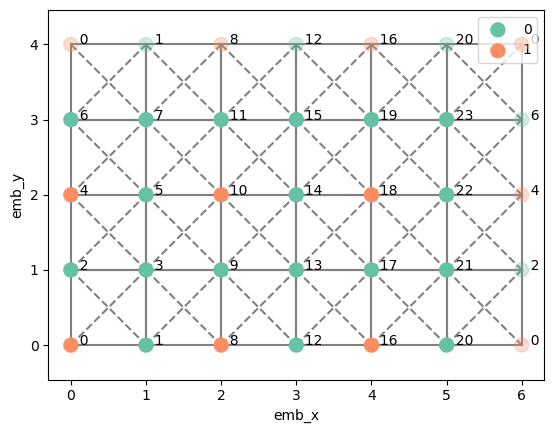

In [29]:
lattice.plot(spins=328977)

In [4]:
def test_weird_segfault_1():
    basis = ls.SpinBasis(8, symmetries=ls.Symmetries([ls.Symmetry([7, 0, 1, 2, 3, 4, 5, 6], 0)]))
    basis.build()
    expr = ls.Expr(
        "σᶻ₀ σᶻ₁ + 2 σ⁺₀ σ⁻₁ + 2 σ⁻₀ σ⁺₁",
        sites=[(i, (i + 1) % basis.number_bits) for i in range(basis.number_bits)],
    )
    hamiltonian = ls.Operator(basis, expr)
    print(ls.SpinBasis.from_json(basis.to_json()))
    print("starting ...")
    print(basis.number_states)
    energy, _ = scipy.sparse.linalg.eigsh(hamiltonian, k=1, which="SA")
    print(energy)

test_weird_segfault_1()

: 